<a href="https://colab.research.google.com/github/bradleywjenks/wds-modelling-optimization-course/blob/main/notebooks/optimal_tank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimal tank operation

This notebook formulates and solves an optimal scheduling problem for a water storage tank. We cover:
- Formulating tank operation as a linear program (LP)
- Solving convex optimization problems with the `cvxpy` Python package
- Regularization to penalize changes in the control variable
- The trade-off between operating cost and smoothness of the schedule

## Setup
Run the cells below first.
- **Google Colab:** the first cell clones (or updates) the repository. The first time, it also installs the `opwater` helper package and its dependencies, then restarts the session (Colab reports that the session crashed; this is expected). **Once it reconnects, run the first cell again**, then continue from the second cell. A pip warning about `numba` and `numpy` can be ignored.
- **Local:** install the repository first (see the README); the first cell then does nothing.

The second cell imports the packages used in this notebook.

In [1]:
import sys

if "google.colab" in sys.modules:
    import importlib.util
    import os

    repo_dir = "/content/wds-modelling-optimization-course"
    if os.path.isdir(repo_dir):
        !git -C {repo_dir} pull --quiet --ff-only
    else:
        !git clone --depth 1 https://github.com/bradleywjenks/wds-modelling-optimization-course.git {repo_dir}

    # install opwater from the clone, unless this runtime already has it
    spec = importlib.util.find_spec("opwater")
    if spec is None or not spec.origin.startswith(repo_dir):
        %pip install --quiet -e {repo_dir}
        print("Restarting the session to load the new packages. Run this cell again once it reconnects.")
        os.kill(os.getpid(), 9)

In [2]:
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

from opwater import data_dir

## Problem formulation
We consider a simplified model of a single tank supplied by a single inflow and serving a single (aggregated) demand. The inflow is pumped and/or treated at a cost that varies over the day, and the tank lets us shift when water is pumped relative to when it is used. Our aim is to find the inflow schedule with the lowest operating cost.

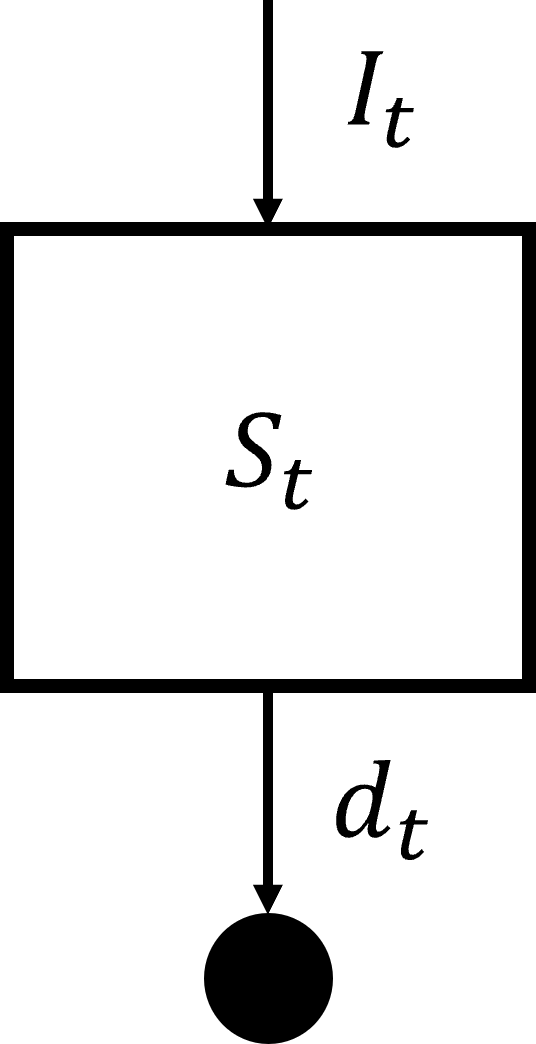

In [3]:
Image(filename=str(data_dir() / "figures" / "tank_illustration.png"), width=120)

The day is divided into $T$ time steps of length $\Delta t$, indexed by $t \in \lbrace 0, \dots, T-1 \rbrace$. The known parameters are:
- $d_t$: water demand during time step $t$ [m$^3$/h]
- $c_t$: unit pumping/treatment cost of the inflow during time step $t$ [currency units per m$^3$]
- $S_{\text{init}}$: initial tank storage [m$^3$]
- $S_{\min}$, $S_{\max}$: minimum and maximum tank storage [m$^3$]
- $I_{\max}$: maximum tank inflow [m$^3$/h]

The decision variables are:
- $I_t$: tank inflow during time step $t \in \lbrace 0, \dots, T-1 \rbrace$ (**control** variable) [m$^3$/h]
- $S_t$: tank storage at the start of time step $t \in \lbrace 0, \dots, T \rbrace$ (**state** variable) [m$^3$], where $S_T$ is the storage at the end of the day

Load the problem data. We use $T = 24$ hourly time steps and an empty tank as the minimum storage.

In [4]:
data = np.load(data_dir() / "optimal_tank" / "tank_operation_data.npz")
d = data["d"]  # demand [m^3/h]
c = data["c"]  # unit cost [per m^3]
S_init = data["S_init"].item()  # initial storage [m^3]
S_max = data["S_max"].item()  # tank capacity [m^3]
I_max = data["I_max"].item()  # maximum inflow [m^3/h]
S_min = 0.0  # minimum storage [m^3]

T = len(d)  # number of time steps
dt = 1.0  # time step [h]
print(f"T = {T}, S_init = {S_init:.0f} m^3, S_max = {S_max:.0f} m^3, I_max = {I_max:.0f} m^3/h")
print(f"Total demand: {d.sum() * dt:.0f} m^3")

T = 24, S_init = 170 m^3, S_max = 570 m^3, I_max = 30 m^3/h
Total demand: 426 m^3


Our objective is to minimize the total pumping/treatment cost

$$
\sum_{t=0}^{T-1} c_t I_t \Delta t,
\tag{1}
$$

subject to mass balance in the tank

$$
S_{t+1} = S_t + (I_t - d_t)\Delta t, \quad t = 0, \dots, T-1,
\tag{2}
$$

the initial and final storage

$$
S_0 = S_{\text{init}}, \quad S_T = S_{\text{init}},
\tag{3}
$$

and the physical limits on storage and inflow

$$
\begin{aligned}
S_{\min} \leq S_t &\leq S_{\max}, \quad t = 0, \dots, T, \\
0 \leq I_t &\leq I_{\max}, \quad t = 0, \dots, T-1.
\end{aligned}
\tag{4}
$$

The final storage constraint in (3) ensures that the tank ends the day where it started, so the same schedule can be repeated the next day. The objective and all constraints are linear in the decision variables, so (1)–(4) is a **linear program** (LP).

## Solving with CVXPY
[CVXPY](https://www.cvxpy.org/) is a Python modelling language for convex optimization problems. We define the decision variables with `cp.Variable`, write the objective and constraints using standard NumPy-like syntax, and CVXPY converts the problem into a standard form and passes it to a numerical solver.

Constraints on vector expressions apply elementwise, so each line below represents all time steps at once: for example,
`S[1:] == S[:-1] + (I - d) * dt` is the mass balance (2) for $t = 0, \dots, T-1$.

In [5]:
# decision variables
S = cp.Variable(T + 1)  # storage [m^3]
I = cp.Variable(T)  # inflow [m^3/h]

# objective (1)
pumping_cost = c @ I * dt

# constraints (2)-(4)
constraints = [
    S[1:] == S[:-1] + (I - d) * dt,  # mass balance
    S[0] == S_init,  # initial storage
    S[T] == S_init,  # final storage
    S >= S_min,
    S <= S_max,
    I >= 0,
    I <= I_max,
]

prob = cp.Problem(cp.Minimize(pumping_cost), constraints)
prob.solve()
print(f"Status: {prob.status}")
print(f"Pumping cost: {prob.value:.2f}")

# save the solution for comparison with the regularized problem below
S_lp = S.value
I_lp = I.value

Status: optimal
Pumping cost: 23.67


Plot the demand, unit cost and optimal tank schedule. The dashed lines show $S_{\max}$ and $I_{\max}$.

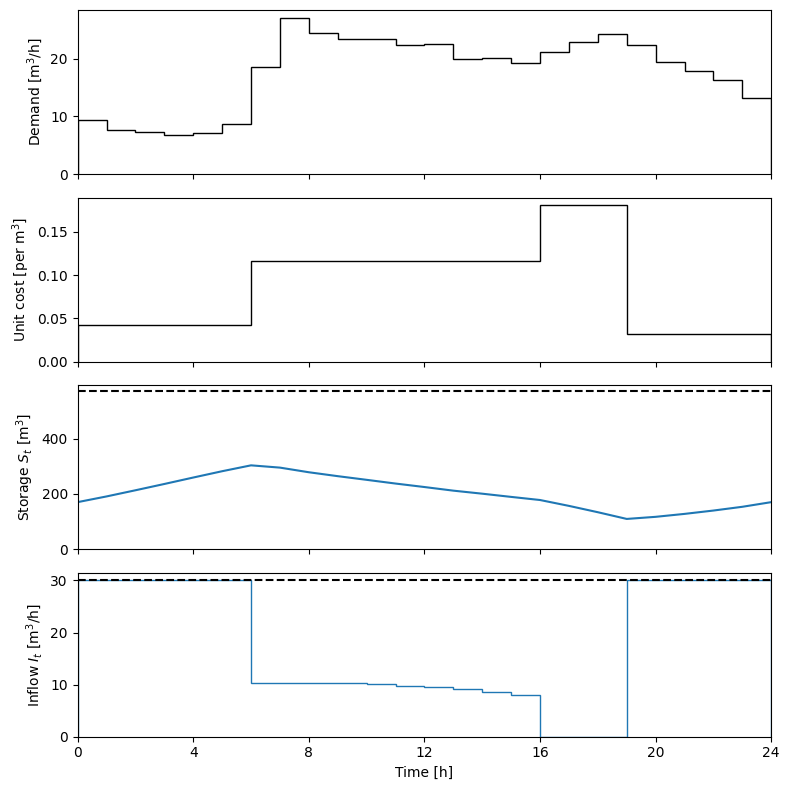

In [6]:
hours = np.arange(T + 1) * dt

fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
axs[0].stairs(d, hours, color="k")
axs[0].set_ylabel("Demand [m$^3$/h]")
axs[1].stairs(c, hours, color="k")
axs[1].set_ylabel("Unit cost [per m$^3$]")
axs[2].plot(hours, S_lp)
axs[2].axhline(S_max, color="k", linestyle="--")
axs[2].set_ylabel("Storage $S_t$ [m$^3$]")
axs[3].stairs(I_lp, hours)
axs[3].axhline(I_max, color="k", linestyle="--")
axs[3].set_ylabel("Inflow $I_t$ [m$^3$/h]")
axs[3].set_xlabel("Time [h]")
axs[3].set_xticks(np.arange(0, 25, 4))
for ax in axs:
    ax.set_xlim(0, T * dt)
    ax.set_ylim(bottom=0)
fig.tight_layout()

The optimal schedule pumps at the maximum rate during the cheap night hours to fill the tank, stops pumping during the expensive evening peak (16:00–19:00) while the tank supplies the demand, then refills the tank once the cost drops again. The tank never reaches $S_{\max}$: the volume that can be stored in the cheap hours is limited by $I_{\max}$.

Between 06:00 and 16:00 the unit cost is constant, so it does not matter *when* in this period the water is pumped: many schedules have the same minimum cost, i.e. the LP solution is **not unique**. An interior point solver such as Clarabel returns a solution from the middle of this optimal set, which explains the gradually decreasing inflow. A simplex solver (e.g. `prob.solve(solver=cp.HIGHS)`) would instead return a vertex of the feasible region, where the inflow tends to switch between its bounds.

## Regularization
Abrupt changes in inflow are undesirable in practice: switching pumps on and off frequently causes wear, and sudden changes in flow can cause pressure transients and water quality problems. We therefore add a second objective that penalizes changes in the inflow $I_t$ between consecutive time steps, using a regularization term with penalty parameter $\lambda \geq 0$:

$$
\sum_{t=0}^{T-1} c_t I_t \Delta t + \lambda \sum_{t=0}^{T-2} \left|I_{t+1} - I_t\right|,
\tag{5}
$$

subject to the same constraints (2)–(4). Regularization also resolves the non-uniqueness of the LP solution: among schedules with (nearly) the same cost, it favours those with fewer and smaller changes in inflow. The regularization term is the $\ell_1$ norm of the vector of inflow changes, also known as the total variation of $I$. It is convex but not differentiable; CVXPY handles this automatically by introducing auxiliary variables to reformulate (5) as an LP. Setting $\lambda = 0$ recovers the original problem.

Complete the code below to solve the regularized problem with $\lambda = 0.1$. The [CVXPY functions](https://www.cvxpy.org/tutorial/functions/index.html) `cp.diff`, `cp.abs`, `cp.sum` and `cp.norm1` may be useful.

In [ ]:
lam = 0.1  # penalty parameter

# decision variables
S = ...
I = ...

# objective (5)
pumping_cost = ...
regularization = ...

# constraints (2)-(4)
constraints = ...

prob = cp.Problem(cp.Minimize(pumping_cost + regularization), constraints)
prob.solve()
print(f"Status: {prob.status}")
print(f"Pumping cost: {pumping_cost.value:.2f} (LP: {c @ I_lp * dt:.2f})")

Compare the storage and inflow schedules with and without regularization.

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(8, 4.5), sharex=True)
axs[0].plot(hours, S_lp, label="LP")
axs[0].plot(hours, S.value, label=f"λ = {lam}")
axs[0].axhline(S_max, color="k", linestyle="--")
axs[0].set_ylabel("Storage $S_t$ [m$^3$]")
axs[0].legend()
axs[1].stairs(I_lp, hours)
axs[1].stairs(I.value, hours)
axs[1].axhline(I_max, color="k", linestyle="--")
axs[1].set_ylabel("Inflow $I_t$ [m$^3$/h]")
axs[1].set_xlabel("Time [h]")
axs[1].set_xticks(np.arange(0, 25, 4))
for ax in axs:
    ax.set_xlim(0, T * dt)
    ax.set_ylim(bottom=0)
fig.tight_layout()

## Questions
Use the code from this notebook to answer the questions below. Complete the code cells marked `TODO`.

### Q1. Penalty parameter
(a) Solve the regularized problem (5) for $\lambda \in \lbrace 0, 0.1, 0.3, 1 \rbrace$ and plot the inflow schedules. How does the inflow schedule change as $\lambda$ increases? What does it become for large $\lambda$, and why?

(b) Solve the problem for many values of $\lambda$ between $10^{-3}$ and $1$ (e.g. `np.logspace(-3, 0, 50)`), recording the pumping cost and the total variation of the inflow, $\sum_t |I_{t+1} - I_t|$. Plot one against the other. How much extra pumping cost does a smoother schedule require? You should find that the solution changes abruptly at a few values of $\lambda$, rather than gradually. Why?

(c) Replace the $\ell_1$ penalty with a quadratic penalty, $\lambda \sum_{t=0}^{T-2} (I_{t+1} - I_t)^2$ (`cp.sum_squares`). How do the shapes of the inflow schedules differ? Which penalty would you choose for pump scheduling?

In [ ]:
# TODO: solve the regularized problem for different values of lambda and plot the inflow schedules

In [ ]:
# TODO: plot the pumping cost against the total variation of the inflow

In [ ]:
# TODO: solve the problem with a quadratic penalty on inflow changes

### Q2. Final storage
(a) Solve the LP (1)–(4) without the final storage constraint $S_T = S_{\text{init}}$. How do the schedule and pumping cost change? Why is this solution not useful in practice?

(b) Replace the final storage constraint with $S_T \geq S_{\text{init}}$. Does the solution differ from the original LP? Explain why.

In [ ]:
# TODO: solve the LP without the final storage constraint, then with S_T >= S_init

### Q3. Tank capacity
(a) Solve the LP (1)–(4) for tank capacities $S_{\max}$ between $100$ and $600$ m$^3$, and plot the optimal pumping cost against $S_{\max}$. What is the smallest capacity for which the problem is feasible, and why? Why does the cost stop decreasing above a certain capacity?

(b) The dual variable of a constraint gives the change in the optimal objective per unit change in the constraint limit. For $S_{\max} = 250$ m$^3$, compute the marginal value of tank capacity, i.e. the cost saving per m$^3$ of extra storage, as the sum of the dual values of the constraint `S <= S_max` over all time steps (`constraints[4].dual_value`). Compare it with the slope of your plot from (a) and with the unit costs $c_t$. What does it represent? What is its value for the original capacity, $S_{\max} = 570$ m$^3$?

*Hint:* if a problem is infeasible, `prob.status` is `"infeasible"`.

In [ ]:
# TODO: solve the LP for a range of tank capacities and plot the optimal pumping cost

## References
- Boyd, S. and Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press.
- Diamond, S. and Boyd, S. (2016). CVXPY: A Python-embedded modelling language for convex optimization. *Journal of Machine Learning Research*, 17(83), 1–5.
- Goulart, P.J. and Chen, Y. (2024). Clarabel: An interior-point solver for conic programs with quadratic objectives. arXiv:2405.12762.